# Assignment:02 ANN & Deep Learning
### Resnet and Unet

| | |
|---|---|
| **Name** | Moeez Umer|
| **Roll No.** | BSCS23150|

---


>
> **Grading (100 marks)**
>
> | Part | Marks |
> |---|---:|
> | Dataset setup, exploration, preprocessing, split (Tasks 1-4, 12-14) | 20 |
> | ResNet-50 modification, training and evaluation (Tasks 5-11) | 25 |
> | U-Net loss, metrics, training and evaluation (Tasks 15-20) | 25 |
> | Results tables (Task 21) and filled-in reports | 5 |
> | Discussion questions and conclusion | 15 |
> | GitHub repository, README, code quality / comments | 10 |

# Table of Contents
1. Introduction
2. Learning Objectives
3. Datasets - where to download them and how to upload them to Google Drive
4. **Step 1** - Environment setup (libraries, GPU, reproducibility)
5. **Step 2** - Mount Google Drive and set the dataset paths
6. **Part A - ResNet-50 Fine-Tuning (Classification)**
    * Step 3 - Explore the flower dataset
    * Step 4 - Preprocessing, augmentation and train/validation/test split
    * Step 5 - ResNet-50 architecture and loading the pretrained model
    * Step 6 - Training utilities
    * Step 7 - Phase 1: feature extraction (frozen backbone)
    * Step 8 - Phase 2: fine-tuning (unfreeze `layer4`)
    * Step 9 - Training curves
    * Step 10 - Evaluation on the test set
7. **Part B - U-Net Fine-Tuning (Segmentation)**
    * Step 11 - Explore the pet segmentation dataset
    * Step 12 - Joint image/mask preprocessing, split and loaders
    * Step 13 - U-Net architecture and model creation
    * Step 14 - Loss function and metrics
    * Step 15 - Phase 1: train the decoder (frozen encoder)
    * Step 16 - Phase 2: fine-tune the encoder
    * Step 17 - Evaluation and visualization






# Introduction
Training a deep convolutional network from scratch needs **tens of thousands of labelled images** and a lot of compute. In practice (medical imaging, agriculture, small company datasets) we often have only **100-200 images**. In such cases we rely on **transfer learning**: we start from a network that was already trained on a very large dataset (ImageNet, 1.2 million images) and **adapt** it to our own small dataset. This adaptation step is called **fine-tuning**.

In this assignment you will fine-tune two of the most important CNN families in computer vision:

| Model | Task | Idea |
|---|---|---|
| **ResNet-50** | Image **classification** (what is in the image?) | Deep CNN with *residual (skip) connections* and bottleneck blocks |
| **U-Net** (with a ResNet-50 encoder) | Image **segmentation** (which pixels belong to the object?) | Encoder-decoder network with *skip connections* between encoder and decoder |



# Datasets (Download -> Upload to Google Drive)

Use **two small datasets** (about **100-200 images** each).

| | Dataset 1 (classification) | Dataset 2 (segmentation) |
|---|---|---|
| **Name** | Oxford Flowers-102 (small subset) | Oxford-IIIT Pet (small subset) |
| **Official page / download** | https://www.robots.ox.ac.uk/~vgg/data/flowers/102/ | https://www.robots.ox.ac.uk/~vgg/data/pets/ |
| **Files** | `102flowers.tgz`, `imagelabels.mat` | `images.tar.gz`, `annotations.tar.gz` |
| **Size to use** | 5 classes x 40 images = **200 images** | **150 image + mask pairs** |
| **Used by** | ResNet-50 | U-Net |


### Required folder structure on Google Drive
```text
MyDrive/
└── ANN_DL_Assignment/
    ├── flowers_subset/              <- classification dataset (ImageFolder format)
    │   ├── flower_class_000/  *.jpg
    │   ├── flower_class_001/  *.jpg
    │   └── ...
    └── pets_subset/                 <- segmentation dataset
        ├── images/   *.jpg
        └── masks/    *.png          <- same file name as the image
```
For the pet masks, the original *trimap* convention is kept: `1 = pet`, `2 = background`, `3 = border`.


# Step 1: Environment Setup
**Before running:** in Colab choose **Runtime -> Change runtime type -> T4 GPU**. Training ResNet-50 and U-Net on a CPU is very slow.

We install `segmentation-models-pytorch` (SMP), which provides U-Net with pretrained encoders, and import all libraries. We also fix the random seeds so that results are **reproducible**.

In [ ]:
# Install the segmentation library (U-Net with pretrained encoders)
!pip install -q segmentation-models-pytorch

In [ ]:
# ---------------- Standard libraries ----------------
import os, random, shutil, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ---------------- PyTorch ----------------
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, models, transforms
import torchvision.transforms.functional as TF

# ---------------- Scikit-learn (splitting + metrics) ----------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_fscore_support)

# ---------------- U-Net library ----------------
import segmentation_models_pytorch as smp

# ---------------- Reproducibility ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------- Device ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("Using device    :", device)
if device.type == "cpu":
    print("WARNING: no GPU found. Go to Runtime > Change runtime type > T4 GPU.")



PyTorch version : 2.11.0+cu130
Using device    : cuda


In [ ]:
# ImageNet statistics: pretrained models expect inputs normalized with them
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Step 2: Mount Google Drive and Set Paths
Colab's local disk is erased when the runtime restarts. **Google Drive** keeps the datasets and trained models permanently. After running the cell below, Google asks for permission to access your Drive - click **Allow**.

In [ ]:
from google.colab import drive

# Mount Google Drive at /content/drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# ---------------- Paths (change BASE_DIR if your folder has a different name) ----------------
BASE_DIR     = "/content/drive/MyDrive/ANN_DL_Assignment"      # main assignment folder on Drive
FLOWERS_DIR  = os.path.join(BASE_DIR, "flowers_subset")    # classification dataset
PETS_DIR     = os.path.join(BASE_DIR, "pets_subset")       # segmentation dataset
PET_IMG_DIR  = os.path.join(PETS_DIR, "images")
PET_MASK_DIR = os.path.join(PETS_DIR, "masks")
CKPT_DIR     = os.path.join(BASE_DIR, "checkpoints")       # trained weights are saved here (Drive)
RESULTS_DIR  = "/content/results"                          # figures/tables (copied to Drive at the end)

for d in [BASE_DIR, CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
print("Base folder exists:", os.path.isdir(BASE_DIR))

Base folder exists: True


---
# PART A - ResNet-50 Fine-Tuning (Classification)
---
# Step 3: Explore the Flower Dataset
Always inspect your data before training: how many images, how many classes, is the dataset balanced, what do images look like, and what sizes do they have?

### Task 1 — Count and plot the images (Step 3)
Complete the cell below.

1. **(1a)** Fill the dictionary `counts` so that it maps each class folder name to its number of images. *Hint:* `os.listdir(os.path.join(FLOWERS_DIR, c))` lists the files of class `c`.
2. **(1b)** Print the number of classes, the total number of images, and the images per class.
3. **(1c)** Draw a bar chart of the class distribution with `plt.bar`.

**Report:** number of classes = 5 , total number of images = 200

Number of classes: 5
Total number of images: 200

Images per class:
flower_class_000: 40
flower_class_001: 40
flower_class_002: 40
flower_class_003: 40
flower_class_004: 40


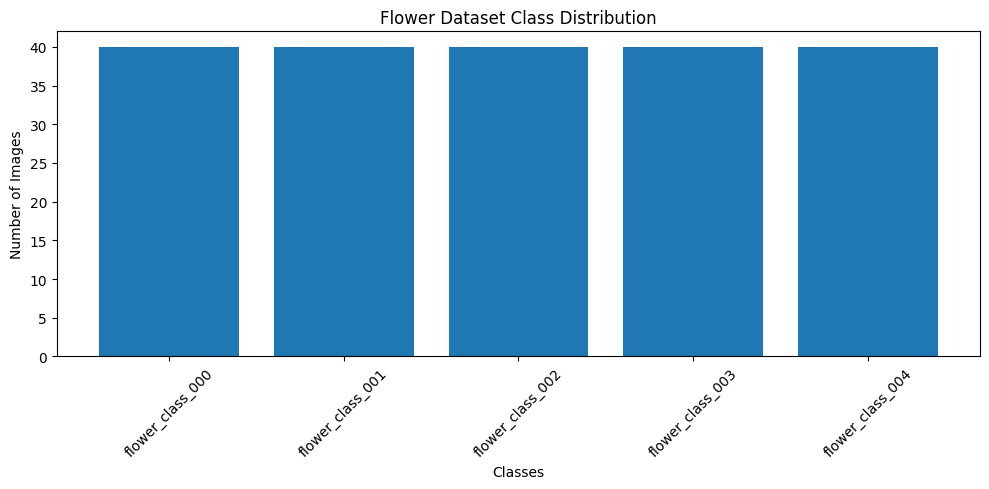

In [ ]:
import os
import matplotlib.pyplot as plt

# List of class folders (given)
class_dirs = sorted(
    d for d in os.listdir(FLOWERS_DIR)
    if os.path.isdir(os.path.join(FLOWERS_DIR, d))
)

# (1a) counts = {class_name: number_of_images}
counts = {}

for c in class_dirs:
    class_path = os.path.join(FLOWERS_DIR, c)
    counts[c] = len(os.listdir(class_path))

# (1b) print number of classes, total images and images per class
num_classes = len(class_dirs)
total_images = sum(counts.values())

print("Number of classes:", num_classes)
print("Total number of images:", total_images)
print("\nImages per class:")

for cls, count in counts.items():
    print(f"{cls}: {count}")

# (1c) bar chart of the class distribution
plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Flower Dataset Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 2 — Show one sample per class (Step 3)
For every class display **one image** with its **class name** and **size (width x height)** in the title.
*Hint:* `Image.open(path).convert("RGB")` gives a PIL image; `img.size` gives `(width, height)`.

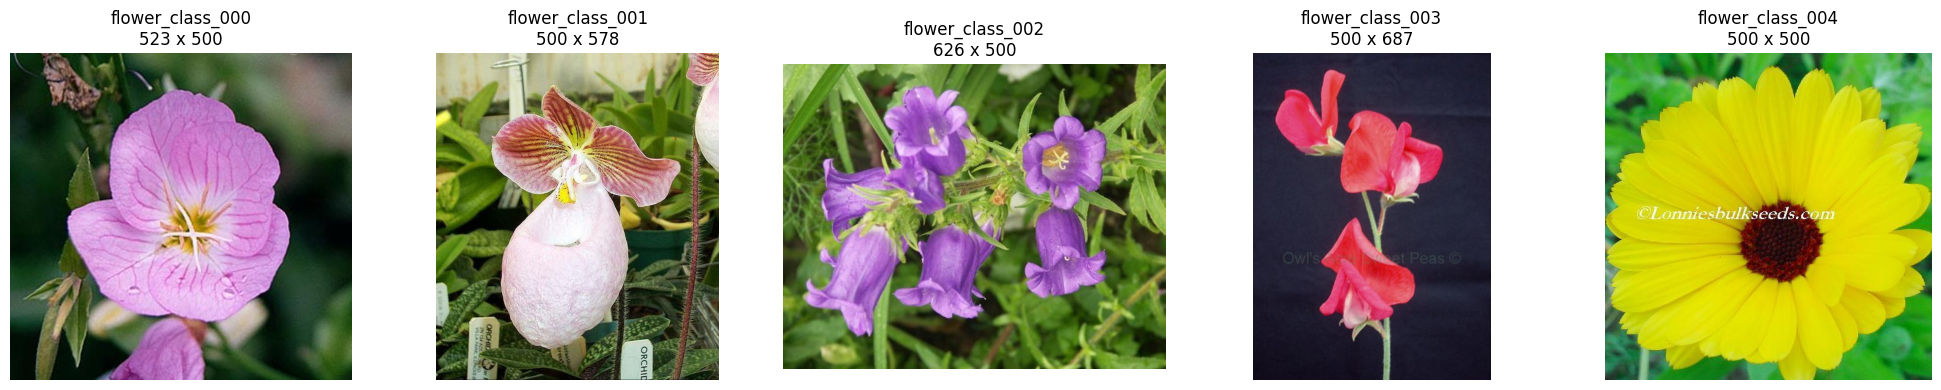

In [ ]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(class_dirs), figsize=(4 * len(class_dirs), 4))

axes = np.atleast_1d(axes)

for ax, c in zip(axes, class_dirs):

    # 1) take the first file name inside the class folder c
    class_path = os.path.join(FLOWERS_DIR, c)
    first_file = sorted(os.listdir(class_path))[0]

    # 2) open the image and convert it to RGB
    img_path = os.path.join(class_path, first_file)
    img = Image.open(img_path).convert("RGB")

    # get image size
    width, height = img.size

    # 3) display image, set title and hide axes
    ax.imshow(img)
    ax.set_title(f"{c}\n{width} x {height}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Step 4: Preprocessing, Augmentation and Data Split

### Why preprocessing?
```text
Original image -> Resize (224x224) -> Augmentation (train only) -> ToTensor -> Normalize (ImageNet mean/std) -> Model
```
* **Resize:** a CNN with a fixed classifier needs a fixed input size (224x224 for ResNet).
* **Augmentation:** random flips/rotations/colour changes create "new" images every epoch. This is the most important regulariser for small datasets. **Never augment validation/test images**, otherwise evaluation becomes noisy.
* **Normalization:** pretrained weights were learned with ImageNet-normalized inputs, so we must use the same mean/std.

### Data split (stratified)
```text
70% Training   -> the model learns from it
15% Validation -> monitor overfitting, pick the best epoch / hyper-parameters
15% Test       -> used ONCE at the end for the final, unbiased score
```
*Stratified* means every class keeps the same proportion in each subset.

### Task 3 — Build the transformation pipelines (Step 4)
Complete `train_tf` with **four** parts, in this order, and `eval_tf` **without augmentation**:

| Part | Transform | Notes |
|---|---|---|
| 1 | Resize | to `(IMG_SIZE, IMG_SIZE)` |
| 2 | Augmentation | random horizontal flip, random rotation (15 degrees), colour jitter (brightness/contrast/saturation 0.2) |
| 3 | Tensor | `transforms.ToTensor()` |
| 4 | Normalize | with `IMAGENET_MEAN`, `IMAGENET_STD` |

*Question to think about:* why must `eval_tf` not contain random augmentation?

In [25]:
IMG_SIZE = 224

train_tf = transforms.Compose([
    # (1) Resize
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # (2) Augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),

    # (3) Convert to tensor
    transforms.ToTensor(),

    # (4) Normalize
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Evaluation transform: resize + tensor + normalize (NO augmentation)
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### Task 4 — Stratified 70/15/15 split and DataLoaders (Step 4)
The two `ImageFolder` objects point to the **same files**: one applies augmentation (`train_tf`), the other does not (`eval_tf`). Complete the following:

* **(4a)** Split the **indices** with `train_test_split` (called twice): 70% train / 30% temp, then split temp 50/50 into validation and test. Use `stratify=` and `random_state=SEED` so every class keeps its proportion.
* **(4b)** Create the four `Subset` objects: `train_ds` (augmented), `train_eval_ds` (train indices but *without* augmentation, used only to measure training accuracy), `val_ds`, `test_ds`.
* **(4c)** Create the four `DataLoader`s (`BATCH = 16`): `train_loader` (shuffle=True), `train_eval_loader`, `val_loader`, `test_loader` (shuffle=False, `num_workers=2`).
* Print the size of each subset.

In [26]:
full_train = datasets.ImageFolder(FLOWERS_DIR, transform=train_tf)   # with augmentation
full_eval  = datasets.ImageFolder(FLOWERS_DIR, transform=eval_tf)    # without augmentation
class_names = full_train.classes
num_classes = len(class_names)
targets     = np.array(full_train.targets)
all_idx     = np.arange(len(targets))
print("Classes:", class_names)

# (4a) train_idx, val_idx, test_idx  (stratified 70/15/15)
train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.30, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED)

# (4b) train_ds, train_eval_ds, val_ds, test_ds
train_ds      = Subset(full_train, train_idx)   # augmented
train_eval_ds = Subset(full_eval,  train_idx)   # same images, no augmentation
val_ds        = Subset(full_eval,  val_idx)
test_ds       = Subset(full_eval,  test_idx)

# (4c) train_loader, train_eval_loader, val_loader, test_loader
BATCH = 16
train_loader      = DataLoader(train_ds,      batch_size=BATCH, shuffle=True,  num_workers=2)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH, shuffle=False, num_workers=2)
val_loader        = DataLoader(val_ds,        batch_size=BATCH, shuffle=False, num_workers=2)
test_loader       = DataLoader(test_ds,       batch_size=BATCH, shuffle=False, num_workers=2)

# print the size of train / validation / test
print(f"Train: {len(train_ds)} | Validation: {len(val_ds)} | Test: {len(test_ds)}")

Classes: ['flower_class_000', 'flower_class_001', 'flower_class_002', 'flower_class_003', 'flower_class_004']
Train: 140 | Validation: 30 | Test: 30


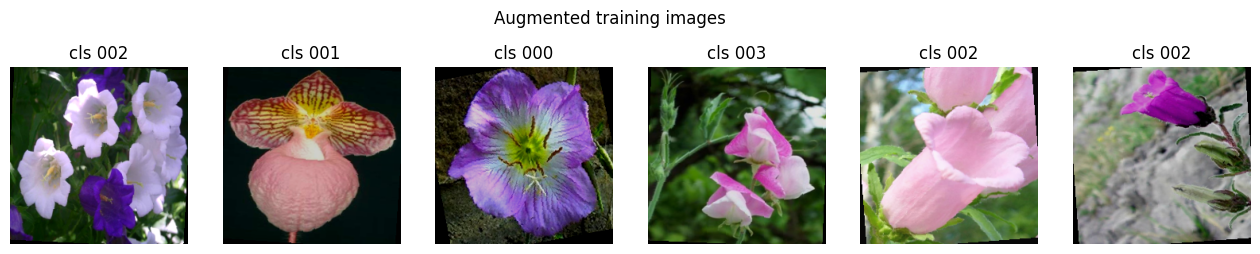

In [27]:
# ---- Visualize augmented training samples ----
MEAN_T = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
STD_T  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denorm(t):
    # Undo ImageNet normalization so that a tensor can be displayed.
    return (t.cpu() * STD_T + MEAN_T).clamp(0, 1).permute(1, 2, 0).numpy()

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for ax, im, lb in zip(axes, imgs[:6], labels[:6]):
    ax.imshow(denorm(im)); ax.set_title(class_names[lb].replace("flower_class_", "cls ")); ax.axis("off")
plt.suptitle("Augmented training images"); plt.show()

# Step 5: ResNet-50 Architecture and Pretrained Model

### Why residual connections?
Very deep plain CNNs become *harder* to train (vanishing gradients, the "degradation problem"). ResNet adds a **skip (identity) connection** so each block learns a *residual* `F(x)` and outputs `F(x) + x`. Gradients flow directly through the shortcut, which makes networks with 50, 101 or 152 layers trainable.

### ResNet-50 overview
```text
Input 224x224x3
   |
7x7 Conv, stride 2 + BatchNorm + ReLU + 3x3 MaxPool
   |
layer1 : 3  bottleneck blocks   (256  channels)
layer2 : 4  bottleneck blocks   (512  channels)
layer3 : 6  bottleneck blocks   (1024 channels)
layer4 : 3  bottleneck blocks   (2048 channels)
   |
Global Average Pooling
   |
Fully connected (fc): 2048 -> 1000 (ImageNet)   <-- we REPLACE this layer
```

### Bottleneck residual block (used by ResNet-50)
```text
x ──────────────────────────────┐   (skip connection; 1x1 conv if shape changes)
│                               │
1x1 Conv (reduce channels) + BN + ReLU
│                               │
3x3 Conv                    + BN + ReLU
│                               │
1x1 Conv (expand channels) + BN
│                               │
└──────────── (+) Addition ◄────┘
               │
              ReLU
```
The 1x1 convolutions reduce and then restore the number of channels, so the expensive 3x3 convolution works on fewer channels (this is the "bottleneck").

### Fine-tuning strategy (2 phases)
```text
ImageNet-pretrained ResNet-50
        |
Replace fc layer (1000 -> number of flower classes)
        |
PHASE 1 - Feature extraction: freeze the whole backbone, train only fc   (lr = 1e-3)
        |
PHASE 2 - Fine-tuning: unfreeze layer4 (+ fc), continue with a smaller lr (lr = 1e-4)
        |
Final model
```
Early layers learn *generic* features (edges, colours, textures); the last layers learn *task-specific* features. Therefore we adapt the last layers first and keep the early ones.

### Task 5 — Modify the ResNet-50 classifier (Step 5)
The pretrained model has a final fully-connected layer `fc` with **1000 outputs** (ImageNet classes). Replace it so that the network predicts **your** `num_classes` flower classes.

1. Read the number of input features of the old layer (`resnet.fc.in_features`).
2. Assign a new `nn.Linear(in_features, num_classes)` to `resnet.fc`.

In [28]:
# Load ResNet-50 pretrained on ImageNet (given)
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
print("Original classifier:", resnet.fc)

# Find the number of input features of the old classifier
in_features = resnet.fc.in_features

# Replace the final layer
resnet.fc = nn.Linear(in_features, num_classes)

resnet = resnet.to(device)
print("New classifier     :", resnet.fc)

def count_params(model):
    # Return (total parameters, trainable parameters).
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, train

print("Total / trainable parameters:", count_params(resnet))

Original classifier: Linear(in_features=2048, out_features=1000, bias=True)
New classifier     : Linear(in_features=2048, out_features=5, bias=True)
Total / trainable parameters: (23518277, 23518277)


# Step 6: Training Utilities
We write the training code **once** and reuse it for both phases.

* `run_epoch_cls` - one pass over a loader. If an optimizer is given it trains, otherwise it evaluates (no gradients).
* `keep_frozen_bn_eval` - **important detail:** `model.train()` also updates the running mean/variance of **BatchNorm** layers, even when their weights are frozen. With a tiny dataset this would corrupt the pretrained statistics, so we keep frozen BatchNorm layers in evaluation mode.
* `fit_cls` - trains for several epochs, records the history and **saves the best model** (highest validation accuracy) to Google Drive.

In [29]:
def keep_frozen_bn_eval(model):
    # Put BatchNorm layers whose parameters are frozen into eval mode (given).
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d) and not any(p.requires_grad for p in m.parameters()):
            m.eval()

### Task 6 — Write the training function `run_epoch_cls` (Step 6)
The function performs **one epoch** over a loader. If an `optimizer` is passed it **trains**, otherwise it only **evaluates**. Inside the loop implement:

1. Move `images` and `labels` to `device`.
2. Forward pass: `outputs = model(images)`.
3. Compute `loss = criterion(outputs, labels)`.
4. **If training:** `optimizer.zero_grad()` -> `loss.backward()` -> `optimizer.step()`.
5. Accumulate `total_loss` (loss x batch size), `correct` (number of correct predictions, use `outputs.argmax(1)`) and `n` (number of samples).

Also define `criterion` (the loss for multi-class classification).

In [31]:
def run_epoch_cls(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)                  # train mode or eval mode
    if training:
        keep_frozen_bn_eval(model)
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(training): # gradients only while training
        for images, labels in loader:
            # 1) move to device
            images, labels = images.to(device), labels.to(device)

            # 2) forward pass
            outputs = model(images)

            # 3) loss
            loss = criterion(outputs, labels)

            # 4) backward + update (only when training)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # 5) accumulate statistics
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            n          += images.size(0)

    return total_loss / n, correct / n

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

In [33]:
# Given: training manager that records the history and saves the BEST model on Google Drive
cls_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
cls_phase_end = []

def fit_cls(model, optimizer, epochs, ckpt_path, scheduler=None):
    best_acc = 0.0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch_cls(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch_cls(model, val_loader, criterion)
        if scheduler: scheduler.step()
        for k, v in zip(cls_history, [tr_loss, va_loss, tr_acc, va_acc]):
            cls_history[k].append(v)
        if va_acc >= best_acc:
            best_acc = va_acc
            torch.save(model.state_dict(), ckpt_path)
        print(f"Epoch {ep:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.3f} | {time.time()-t0:.1f}s")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))   # restore best weights
    cls_phase_end.append(len(cls_history["val_acc"]))
    return best_acc

# Step 7: Phase 1 - Feature Extraction (Frozen Backbone)
We **freeze** every pretrained layer (`requires_grad = False`) and train only the new `fc` layer. The optimizer receives only the trainable parameters. We use `AdamW` with a relatively large learning rate (1e-3) because the new layer is randomly initialized.

### Task 7 — Phase 1: freeze the backbone and train the classifier (Step 7)
* **(7a)** Freeze **all** parameters of `resnet` (`requires_grad = False`), then unfreeze only `resnet.fc`.
* **(7b)** Create the optimizer `optim.AdamW` that receives **only trainable parameters** (`filter(lambda p: p.requires_grad, ...)`), `lr=1e-3`, `weight_decay=1e-4`.
* Run the training (given). Record the number of trainable parameters.

**Report:** trainable parameters in Phase 1 = 10,245 ; best validation accuracy = 0.900

In [35]:
import os

CKPT_DIR = "/content/drive/MyDrive"

os.makedirs(CKPT_DIR, exist_ok=True)

print("Checkpoint directory:", CKPT_DIR)
print("Exists:", os.path.exists(CKPT_DIR))
print("Writable:", os.access(CKPT_DIR, os.W_OK))

Checkpoint directory: /content/drive/MyDrive
Exists: True
Writable: True


In [36]:
# (7a) freeze the backbone, keep only the new classifier trainable
for p in resnet.parameters():
    p.requires_grad = False
for p in resnet.fc.parameters():
    p.requires_grad = True

total, trainable = count_params(resnet)
print(f"Phase 1 -> trainable parameters: {trainable:,} of {total:,}")

# (7b) optimizer
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, resnet.parameters()),
                        lr=1e-3, weight_decay=1e-4)

# Training (given)
phase1_best = fit_cls(resnet, optimizer, epochs=10, ckpt_path=os.path.join(CKPT_DIR, "resnet50_phase1.pth"))
print(f"Best validation accuracy after Phase 1: {phase1_best:.3f}")

Phase 1 -> trainable parameters: 10,245 of 23,518,277
Epoch 01/10 | train loss 1.1669 acc 0.793 | val loss 1.0572 acc 0.867 | 2.1s
Epoch 02/10 | train loss 0.9158 acc 0.914 | val loss 0.8868 acc 0.900 | 2.2s
Epoch 03/10 | train loss 0.7535 acc 0.936 | val loss 0.7584 acc 0.867 | 3.0s
Epoch 04/10 | train loss 0.6424 acc 0.943 | val loss 0.6687 acc 0.867 | 2.0s
Epoch 05/10 | train loss 0.5518 acc 0.936 | val loss 0.5957 acc 0.900 | 2.0s
Epoch 06/10 | train loss 0.4861 acc 0.950 | val loss 0.5408 acc 0.900 | 2.1s
Epoch 07/10 | train loss 0.4272 acc 0.943 | val loss 0.5012 acc 0.900 | 2.1s
Epoch 08/10 | train loss 0.3817 acc 0.964 | val loss 0.4648 acc 0.900 | 2.1s
Epoch 09/10 | train loss 0.3609 acc 0.943 | val loss 0.4361 acc 0.900 | 3.0s
Epoch 10/10 | train loss 0.3121 acc 0.971 | val loss 0.4124 acc 0.900 | 2.8s
Best validation accuracy after Phase 1: 0.900


# Step 8: Phase 2 - Fine-Tuning (Unfreeze `layer4`)
Now we also **unfreeze `layer4`** (the deepest, most task-specific block) and train it together with `fc`. The learning rate is **10x smaller (1e-4)** so that the pretrained weights are adjusted gently and not destroyed. A cosine scheduler lowers the learning rate smoothly during training.

### Task 8 — Phase 2: fine-tune `layer4` (Step 8)
* **(8a)** Unfreeze the last residual stage `resnet.layer4`.
* **(8b)** Create a **new** `AdamW` optimizer with a **smaller learning rate (1e-4)** over the trainable parameters.

**Report:** trainable parameters in Phase 2 = 14,974,981 ; best validation accuracy = 0.967 ; did fine-tuning help? Yes. Validation accuracy rose from 0.900 to 0.967 and validation loss fell from 0.412 to about 0.148

In [37]:
# (8a) unfreeze layer4
for p in resnet.layer4.parameters():
    p.requires_grad = True

total, trainable = count_params(resnet)
print(f"Phase 2 -> trainable parameters: {trainable:,} of {total:,}")

# (8b) new optimizer with a smaller learning rate
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, resnet.parameters()),
                        lr=1e-4, weight_decay=1e-4)

# Scheduler + training (given)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
phase2_best = fit_cls(resnet, optimizer, epochs=10, ckpt_path=os.path.join(CKPT_DIR, "resnet50_best.pth"), scheduler=scheduler)
print(f"Best validation accuracy after Phase 2: {phase2_best:.3f}")

Phase 2 -> trainable parameters: 14,974,981 of 23,518,277
Epoch 01/10 | train loss 0.7714 acc 0.707 | val loss 0.3669 acc 0.967 | 4.5s
Epoch 02/10 | train loss 0.4187 acc 0.957 | val loss 0.3120 acc 0.967 | 3.7s
Epoch 03/10 | train loss 0.2057 acc 1.000 | val loss 0.2243 acc 0.967 | 2.2s
Epoch 04/10 | train loss 0.1006 acc 0.993 | val loss 0.1852 acc 0.967 | 2.1s
Epoch 05/10 | train loss 0.0553 acc 1.000 | val loss 0.1531 acc 0.967 | 2.2s
Epoch 06/10 | train loss 0.0360 acc 1.000 | val loss 0.1475 acc 0.967 | 2.1s
Epoch 07/10 | train loss 0.0387 acc 1.000 | val loss 0.1485 acc 0.967 | 3.0s
Epoch 08/10 | train loss 0.0235 acc 1.000 | val loss 0.1523 acc 0.967 | 2.9s
Epoch 09/10 | train loss 0.0492 acc 0.993 | val loss 0.1499 acc 0.967 | 2.1s
Epoch 10/10 | train loss 0.0301 acc 1.000 | val loss 0.1495 acc 0.967 | 2.2s
Best validation accuracy after Phase 2: 0.967


# Step 9: Training Curves
Curves reveal overfitting: if training accuracy keeps rising while validation accuracy stagnates or falls (and validation loss rises), the model memorizes the training set. The dashed line marks the start of Phase 2.

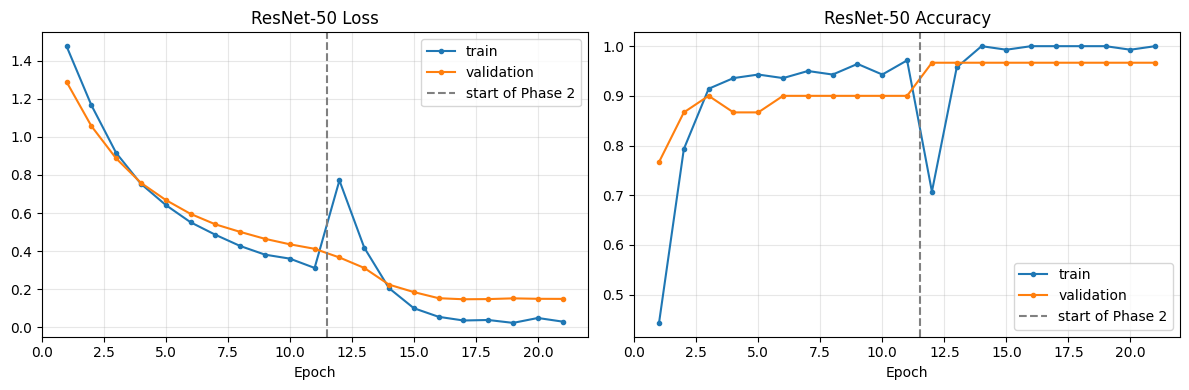

In [38]:
def plot_history(hist, phase_end, keys, titles, save_path):
    # Plot train/val curves for each metric pair with a line where Phase 2 starts.
    fig, axes = plt.subplots(1, len(keys), figsize=(6 * len(keys), 4))
    axes = np.atleast_1d(axes)
    for ax, (tr, va), title in zip(axes, keys, titles):
        ax.plot(range(1, len(hist[tr]) + 1), hist[tr], label="train", marker="o", ms=3)
        ax.plot(range(1, len(hist[va]) + 1), hist[va], label="validation", marker="o", ms=3)
        if len(phase_end) > 1:
            ax.axvline(phase_end[0] + 0.5, color="gray", ls="--", label="start of Phase 2")
        ax.set_xlabel("Epoch"); ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.show()

plot_history(cls_history, cls_phase_end,
             keys=[("train_loss", "val_loss"), ("train_acc", "val_acc")],
             titles=["ResNet-50 Loss", "ResNet-50 Accuracy"],
             save_path=os.path.join(RESULTS_DIR, "resnet_results.png"))

# Step 10: Evaluation on the Test Set
We now evaluate the best model on the **test set**, which was never used for training or model selection. Metrics:

* **Accuracy** = correct predictions / all predictions.
* **Precision** = of the images predicted as class *c*, how many really are *c*.
* **Recall** = of all images of class *c*, how many were found.
* **F1-score** = harmonic mean of precision and recall.
* **Confusion matrix** = rows are true classes, columns are predicted classes; off-diagonal cells are mistakes.

### Task 9 — Test-set predictions and metrics (Step 10)
* **(9a)** Complete `predict_loader`: for every batch run the model, take `argmax(1)` as the prediction and store true and predicted labels.
* **(9b)** Compute `resnet_train_acc`, `resnet_val_acc`, `resnet_test_acc` (use `accuracy_score`) and the **macro** `resnet_prec`, `resnet_rec`, `resnet_f1` on the **test set** (`precision_recall_fscore_support(..., average="macro")`).
* **(9c)** Print the `classification_report` of the test set.

In [39]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for images, labels in loader:
        # forward pass, argmax, append to y_true / y_pred
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())
    return np.array(y_true), np.array(y_pred)

yt_tr, yp_tr = predict_loader(resnet, train_eval_loader)
yt_va, yp_va = predict_loader(resnet, val_loader)
yt_te, yp_te = predict_loader(resnet, test_loader)

# (9b) accuracies and macro precision / recall / F1
resnet_train_acc = resnet_val_acc = resnet_test_acc = None
resnet_prec = resnet_rec = resnet_f1 = None
resnet_train_acc = accuracy_score(yt_tr, yp_tr)
resnet_val_acc   = accuracy_score(yt_va, yp_va)
resnet_test_acc  = accuracy_score(yt_te, yp_te)
resnet_prec, resnet_rec, resnet_f1, _ = precision_recall_fscore_support(
    yt_te, yp_te, average="macro", zero_division=0)

print(f"Train acc: {resnet_train_acc:.4f} | Val acc: {resnet_val_acc:.4f} | Test acc: {resnet_test_acc:.4f}")
print(f"Macro Precision: {resnet_prec:.4f} | Recall: {resnet_rec:.4f} | F1: {resnet_f1:.4f}")

# (9c) classification report
print(classification_report(yt_te, yp_te, target_names=class_names, zero_division=0))

Train acc: 1.0000 | Val acc: 0.9667 | Test acc: 1.0000
Macro Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000
                  precision    recall  f1-score   support

flower_class_000       1.00      1.00      1.00         6
flower_class_001       1.00      1.00      1.00         6
flower_class_002       1.00      1.00      1.00         6
flower_class_003       1.00      1.00      1.00         6
flower_class_004       1.00      1.00      1.00         6

        accuracy                           1.00        30
       macro avg       1.00      1.00      1.00        30
    weighted avg       1.00      1.00      1.00        30



### Task 10 — Confusion matrix and hardest class (Step 10)
1. Compute the confusion matrix `cm` of the test set (`confusion_matrix`).
2. Display it with `ConfusionMatrixDisplay` and save the figure as `results/resnet_confusion_matrix.png` (`plt.savefig(os.path.join(RESULTS_DIR, ...))`).
3. Compute the **accuracy of each class** (diagonal / row sum) and store the name of the worst class in `hardest_class`.

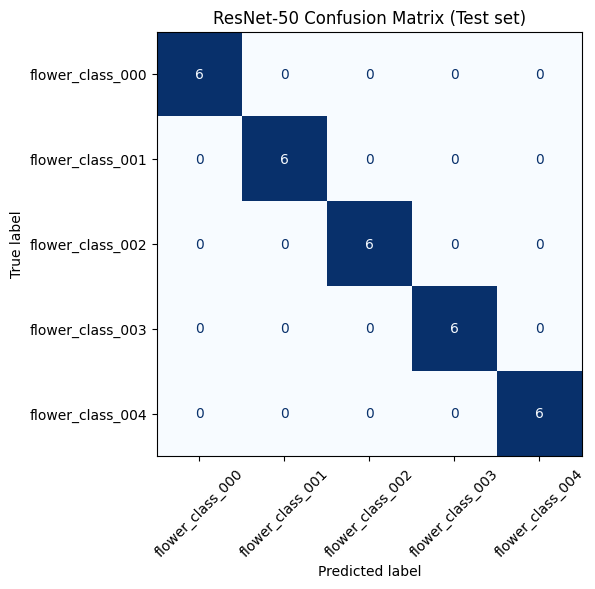

flower_class_000: 1.000
flower_class_001: 1.000
flower_class_002: 1.000
flower_class_003: 1.000
flower_class_004: 1.000
Hardest class: flower_class_000


In [40]:
# Confusion matrix of the test set
cm = confusion_matrix(yt_te, yp_te)

# Display and save
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("ResNet-50 Confusion Matrix (Test set)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "resnet_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# Accuracy per class = diagonal / row sum
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for name, acc in zip(class_names, per_class_acc):
    print(f"{name}: {acc:.3f}")

hardest_class = class_names[int(np.argmin(per_class_acc))]
print("Hardest class:", hardest_class)

### Task 11 — Look at the mistakes (Step 10)
Find the indices where `yt_te != yp_te` and show up to **6 misclassified test images** with their true and predicted class. *Hint:* use `test_ds[i]` to get an image and the `denorm()` helper to display it.

**Observation:** why might the model confuse these images?
The model made no mistakes (0 of 30 test images), so there are no misclassified images to analyse. Something like: The fine-tuned ResNet-50 classified all 30 test images correctly, because the 5 flower classes are visually distinct and ImageNet features already separate them well. With only 30 test images, 100% should be read cautiously, since one or two harder images would change the score noticeably

In [41]:
wrong_idx = np.where(yt_te != yp_te)[0]
print(f"Misclassified test images: {len(wrong_idx)} of {len(yt_te)}")

if len(wrong_idx) == 0:
    print("No mistakes on the test set.")
else:
    show = wrong_idx[:6]
    fig, axes = plt.subplots(1, len(show), figsize=(3.5 * len(show), 4))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, show):
        img, _ = test_ds[i]
        ax.imshow(denorm(img))
        ax.set_title(f"True: {class_names[yt_te[i]].replace('flower_class_', 'cls ')}\n"
                     f"Pred: {class_names[yp_te[i]].replace('flower_class_', 'cls ')}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Misclassified test images")
    plt.tight_layout(); plt.show()

Misclassified test images: 0 of 30
No mistakes on the test set.


---
# PART B - U-Net Fine-Tuning (Segmentation)
---
# Step 11: Explore the Pet Segmentation Dataset
Segmentation assigns a label to **every pixel**. Each training example consists of:
```text
Image (RGB)  +  Ground-truth mask (same height/width)
```
The original masks are *trimaps*: `1 = pet`, `2 = background`, `3 = border`. We convert them to a **binary mask**: `pet (1 and 3) -> 1`, `background (2) -> 0`. First we verify that every image has a mask.

### Task 12 — Verify the image/mask pairs (Step 11)
* **(12a)** Fill `img_files` and `mask_files`: dictionaries mapping the **file-name stem** (name without extension, `os.path.splitext`) to the file name.
* **(12b)** Compute `pair_stems` = sorted list of stems present in **both** dictionaries and print: number of images, number of masks, number of valid pairs.
* **(12c)** Display **4 samples** (image on top, binary mask below). The function `load_binary_mask` is given.

**Report:** images = 150 , masks = 150 , valid pairs = 150

Number of images : 150
Number of masks  : 150
Valid pairs      : 150


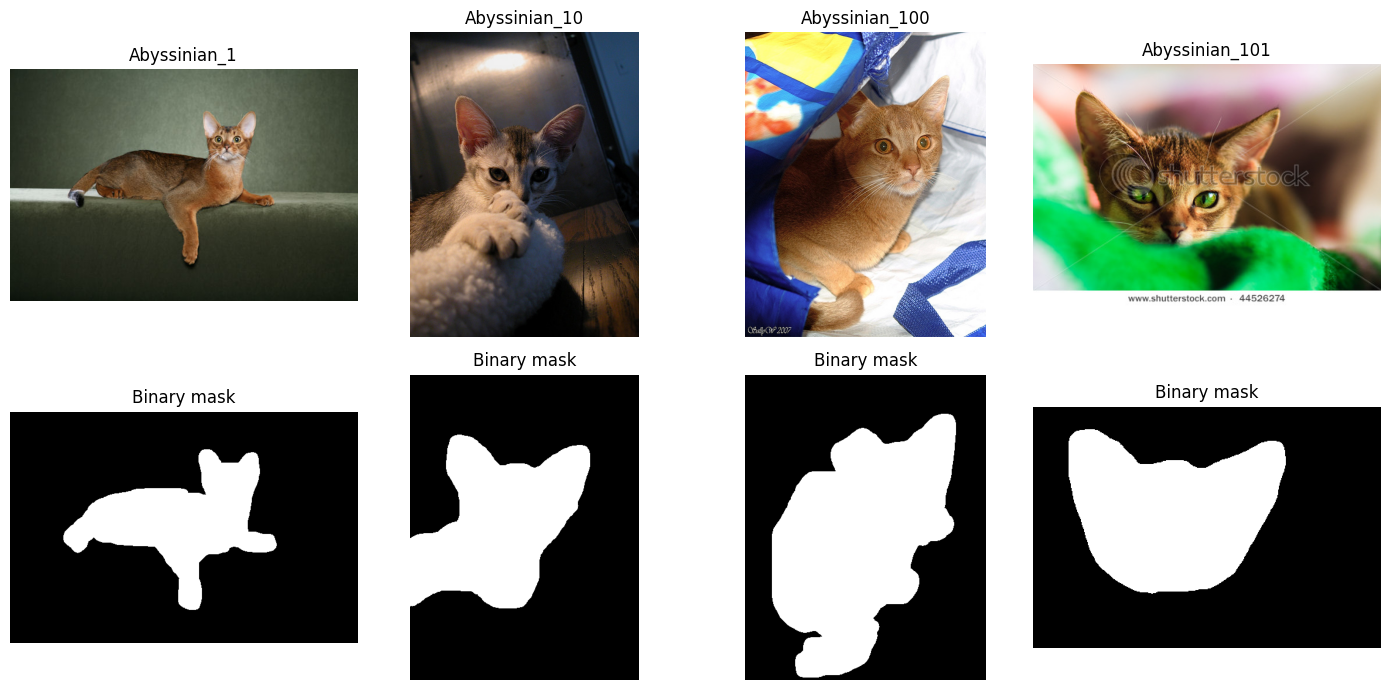

In [42]:
# (12a) dictionaries stem -> file name
img_files, mask_files = {}, {}
for f in sorted(os.listdir(PET_IMG_DIR)):
    if f.startswith("."): continue
    img_files[os.path.splitext(f)[0]] = f
for f in sorted(os.listdir(PET_MASK_DIR)):
    if f.startswith("."): continue
    mask_files[os.path.splitext(f)[0]] = f

# (12b) pairs and printing
pair_stems = sorted(set(img_files) & set(mask_files))
print("Number of images :", len(img_files))
print("Number of masks  :", len(mask_files))
print("Valid pairs      :", len(pair_stems))

def load_binary_mask(path):
    # Read a trimap and convert it to a binary mask (255 = pet, 0 = background). (given)
    arr = np.array(Image.open(path).convert("L"))
    return Image.fromarray((((arr == 1) | (arr == 3)) * 255).astype(np.uint8))

# (12c) visualize 4 image/mask samples (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, s in enumerate(pair_stems[:4]):
    img = Image.open(os.path.join(PET_IMG_DIR, img_files[s])).convert("RGB")
    msk = load_binary_mask(os.path.join(PET_MASK_DIR, mask_files[s]))
    axes[0, j].imshow(img);                axes[0, j].set_title(s); axes[0, j].axis("off")
    axes[1, j].imshow(msk, cmap="gray");   axes[1, j].set_title("Binary mask"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()

# Step 12: Joint Image/Mask Preprocessing, Split and Loaders
> **Golden rule:** every *spatial* transformation (resize, flip, rotation) must be applied **identically** to the image **and** its mask:
> ```text
> Image ── Horizontal Flip ──► Augmented Image
> Mask  ── Horizontal Flip ──► Augmented Mask
> ```
Additional rules used below:
* Masks are resized/rotated with **nearest-neighbour** interpolation so values stay 0 or 1 (no blurred labels).
* Colour changes and normalization are applied to the **image only**.
* Images are resized to **256x256** (U-Net needs sizes divisible by 32).

### Task 13 — Segmentation dataset with joint transforms (Step 12)
Complete `__getitem__` of `PetSegDataset`. Remember the **golden rule**: *the same spatial transformation must be applied to the image and its mask.*

1. **Resize** both to `size x size` — the mask with `interpolation=TF.InterpolationMode.NEAREST`.
2. **If `self.train`:** random horizontal flip (probability 0.5, **same decision** for image and mask); random rotation by the **same angle** (use `TF.rotate`, mask with NEAREST); brightness/contrast change on the **image only**.
3. Image: `TF.to_tensor` then `TF.normalize(..., IMAGENET_MEAN, IMAGENET_STD)`. Mask: `TF.to_tensor` and convert to binary float `(mask > 0.5).float()`.

*Question:* why is NEAREST interpolation used for masks?

In [48]:
SEG_SIZE = 256

class PetSegDataset(Dataset):
    def __init__(self, stems, train=False, size=SEG_SIZE):
        self.stems, self.train, self.size = stems, train, size

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, i):
        s = self.stems[i]
        image = Image.open(os.path.join(PET_IMG_DIR, img_files[s])).convert("RGB")
        mask  = load_binary_mask(os.path.join(PET_MASK_DIR, mask_files[s]))   # binary mask

        # Step 1: resize
        image = TF.resize(image, [self.size, self.size])
        mask  = TF.resize(mask,  [self.size, self.size],
                          interpolation=TF.InterpolationMode.NEAREST)

        # Step 2: augmentation (only when self.train is True)
        if self.train:
            # random horizontal flip: one decision for both
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)

            # random rotation: same angle for both
            angle = random.uniform(-15, 15)
            image = TF.rotate(image, angle)
            mask  = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST)

            # brightness / contrast: image only
            image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
            image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))

        # Step 3: tensor + normalize (image), tensor + binarize (mask)
        image = TF.to_tensor(image)
        image = TF.normalize(image, IMAGENET_MEAN, IMAGENET_STD)
        mask  = (TF.to_tensor(mask) > 0.5).float()

        return image, mask

### Task 14 — Split and DataLoaders for segmentation (Step 12)
Shuffle `stems` (already done, reproducible) and split **70/15/15**. Create `seg_train_ds` (with `train=True`), `seg_val_ds`, `seg_test_ds`, then the three loaders `seg_train_loader` (shuffle), `seg_val_loader`, `seg_test_loader` with `SEG_BATCH = 8`. Print the size of each subset.

In [49]:
stems = list(pair_stems)
random.Random(SEED).shuffle(stems)

# 70 / 15 / 15 split and datasets
n = len(stems)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
train_stems = stems[:n_train]
val_stems   = stems[n_train:n_train + n_val]
test_stems  = stems[n_train + n_val:]

seg_train_ds = PetSegDataset(train_stems, train=True)
seg_val_ds   = PetSegDataset(val_stems,   train=False)
seg_test_ds  = PetSegDataset(test_stems,  train=False)

SEG_BATCH = 8
# DataLoaders
seg_train_loader = DataLoader(seg_train_ds, batch_size=SEG_BATCH, shuffle=True,  num_workers=2)
seg_val_loader   = DataLoader(seg_val_ds,   batch_size=SEG_BATCH, shuffle=False, num_workers=2)
seg_test_loader  = DataLoader(seg_test_ds,  batch_size=SEG_BATCH, shuffle=False, num_workers=2)

print(f"Train: {len(seg_train_ds)} | Validation: {len(seg_val_ds)} | Test: {len(seg_test_ds)}")

Train: 105 | Validation: 22 | Test: 23


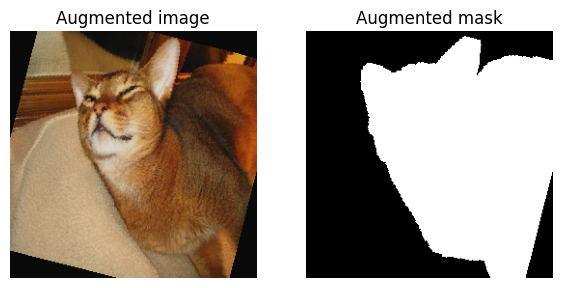

In [50]:
# Given: check that the image and mask are still aligned after augmentation
im, mk = seg_train_ds[0]
fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))
ax[0].imshow(denorm(im)); ax[0].set_title("Augmented image"); ax[0].axis("off")
ax[1].imshow(mk[0], cmap="gray"); ax[1].set_title("Augmented mask"); ax[1].axis("off")
plt.show()

# Step 13: U-Net Architecture and Model Creation
U-Net is an **encoder-decoder** network designed for pixel-wise prediction.

```text
                         U-NET (ResNet-50 encoder)

Input Image (256x256x3)
     │
     ▼
┌─────────────┐
│ Encoder 1   │───────────────┐         Encoder  : a ResNet-50 that extracts increasingly
└─────────────┘               │                    abstract features while halving the resolution
     │                        │
     ▼                        │         Skip     : encoder feature maps are copied (concatenated)
┌─────────────┐               │         connect.   to the decoder at the SAME resolution, giving the
│ Encoder 2   │──────────┐    │                    decoder the fine spatial detail lost by pooling
└─────────────┘          │    │
     │                   │    │         Bottleneck: deepest, most abstract representation
     ▼                   │    │
┌─────────────┐          │    │         Decoder  : up-sampling + convolution blocks that
│ Encoder 3   │─────┐    │    │                    rebuild the spatial resolution step by step
└─────────────┘     │    │    │
     │              │    │    │         Head     : 1x1 conv -> 1 channel (logit per pixel)
     ▼              │    │    │
┌─────────────┐     │    │    │
│ Bottleneck  │     │    │    │
└─────────────┘     │    │    │
     │              │    │    │
     ▼              │    │    │
┌─────────────┐     │    │    │
│ Decoder 3   │◄────┘    │    │
└─────────────┘          │    │
     │                   │    │
     ▼                   │    │
┌─────────────┐          │    │
│ Decoder 2   │◄─────────┘    │
└─────────────┘               │
     │                        │
     ▼                        │
┌─────────────┐               │
│ Decoder 1   │◄──────────────┘
└─────────────┘
     │
     ▼
Segmentation Mask (256x256x1)
```
**Why a pretrained encoder?** With only ~100 training images, a randomly initialized encoder would overfit. The ImageNet-pretrained ResNet-50 encoder already extracts good edges/textures/shapes, so we mainly have to train the **decoder** and gently adapt the encoder.

**Fine-tuning strategy** (same idea as ResNet): Phase 1 freeze the encoder and train decoder + head; Phase 2 unfreeze the last encoder stages (`layer3`, `layer4`) with a smaller learning rate.

In [51]:
# U-Net with a pretrained ResNet-50 encoder, 1 output channel (binary mask), outputs raw logits
unet = smp.Unet(
    encoder_name="resnet50",       # ResNet-50 backbone as the encoder
    encoder_weights="imagenet",    # pretrained on ImageNet
    in_channels=3,                 # RGB
    classes=1,                     # binary segmentation: 1 logit per pixel
).to(device)

total, trainable = count_params(unet)
enc_total = sum(p.numel() for p in unet.encoder.parameters())
print(f"Total parameters: {total:,} | Encoder: {enc_total:,} | Decoder + head: {total - enc_total:,}")

# Quick shape test: input [2,3,256,256] -> output must be [2,1,256,256]
with torch.no_grad():
    print("Output shape:", unet(torch.randn(2, 3, SEG_SIZE, SEG_SIZE).to(device)).shape)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Total parameters: 32,521,105 | Encoder: 23,508,032 | Decoder + head: 9,013,073
Output shape: torch.Size([2, 1, 256, 256])


# Step 14: Loss Function and Metrics

### Loss = BCE + Dice
* **Binary Cross-Entropy (BCE)** treats every pixel as an independent classification problem.
* **Dice loss** `= 1 - Dice` directly optimizes the *overlap* between prediction and ground truth. It is robust to **class imbalance** (the pet may cover only a small part of the image, so "predict everything background" would give a low BCE but a bad Dice).

### Metrics
```text
Dice = 2 x |Prediction ∩ Ground Truth| / ( |Prediction| + |Ground Truth| )

IoU  =     |Prediction ∩ Ground Truth| /   |Prediction ∪ Ground Truth|
```
Both range from 0 (no overlap) to 1 (perfect). IoU is always <= Dice for the same prediction. Predicted probabilities are thresholded at 0.5 for the metrics.

### Task 15 — Segmentation loss and metrics (Step 14)
Implement the following functions. Inputs are **logits** (`[B,1,H,W]`) and binary `targets` of the same shape. Sum over the dimensions `(1, 2, 3)` to get one value per image, then average over the batch. Use `eps=1e-6` to avoid division by zero.

| Function | Definition | Notes |
|---|---|---|
| `dice_loss` | `1 - mean( (2*inter + eps) / (union + eps) )` | uses **probabilities** `torch.sigmoid(logits)`; `union = sum(p) + sum(target)` |
| `seg_loss` | `BCE + Dice loss` | use `bce_loss_fn` |
| `dice_score` | same formula as above | uses the **thresholded** prediction `(sigmoid > 0.5).float()`; return `.item()` |
| `iou_score` | `(inter + eps) / (union + eps)` | here `union = sum(pred) + sum(target) - inter`; return `.item()` |

```text
Dice = 2 x |Prediction ∩ Ground Truth| / ( |Prediction| + |Ground Truth| )
IoU  =     |Prediction ∩ Ground Truth| /   |Prediction ∪ Ground Truth|
```

In [52]:
bce_loss_fn = nn.BCEWithLogitsLoss()      # includes the sigmoid -> the model outputs logits

def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    inter = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + eps) / (union + eps)).mean()

def seg_loss(logits, targets):
    return bce_loss_fn(logits, targets) + dice_loss(logits, targets)

def dice_score(logits, targets, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean().item()

def iou_score(logits, targets, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()

def pixel_accuracy(logits, targets):
    # Fraction of correctly classified pixels (given)
    return ((torch.sigmoid(logits) > 0.5).float() == targets).float().mean().item()

### Task 16 — One segmentation epoch (Step 14)
Complete `run_epoch_seg`: for every batch move data to `device`, forward pass, `loss = seg_loss(logits, masks)`, **if training** `zero_grad -> backward -> step`, and accumulate the **loss, Dice and IoU** weighted by the batch size `k = images.size(0)`. Return `(avg loss, avg dice, avg iou)`.

In [53]:
def run_epoch_seg(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    if training:
        keep_frozen_bn_eval(model)
    tot_loss = tot_dice = tot_iou = n = 0

    with torch.set_grad_enabled(training):
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss = seg_loss(logits, masks)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            k = images.size(0)
            tot_loss += loss.item() * k
            tot_dice += dice_score(logits, masks) * k
            tot_iou  += iou_score(logits, masks) * k
            n += k

    return tot_loss / n, tot_dice / n, tot_iou / n

In [54]:
# Given: training manager (keeps the checkpoint with the best validation Dice)
seg_history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": [], "train_iou": [], "val_iou": []}
seg_phase_end = []

def fit_seg(model, optimizer, epochs, ckpt_path, scheduler=None):
    best = 0.0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        trl, trd, tri = run_epoch_seg(model, seg_train_loader, optimizer)
        val, vad, vai = run_epoch_seg(model, seg_val_loader)
        if scheduler: scheduler.step()
        for k, v in zip(seg_history, [trl, val, trd, vad, tri, vai]):
            seg_history[k].append(v)
        if vad >= best:
            best = vad
            torch.save(model.state_dict(), ckpt_path)
        print(f"Epoch {ep:02d}/{epochs} | train loss {trl:.4f} dice {trd:.3f} | "
              f"val loss {val:.4f} dice {vad:.3f} iou {vai:.3f} | {time.time()-t0:.1f}s")
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    seg_phase_end.append(len(seg_history["val_dice"]))
    return best

# Step 15: Phase 1 - Train the Decoder (Frozen Encoder)
The pretrained ResNet-50 encoder is frozen; only the randomly initialized decoder and segmentation head are trained (lr = 1e-3).

### Task 17 — U-Net Phase 1: freeze the encoder (Step 15)
* **(17a)** Freeze **all** parameters of `unet.encoder`.
* **(17b)** Create `AdamW` over the trainable parameters (`lr=1e-3`, `weight_decay=1e-4`).

**Report:** trainable parameters = 9,013,073 ; best validation Dice after Phase 1 = 0.935

In [55]:
# (17a) freeze the encoder
for p in unet.encoder.parameters():
    p.requires_grad = False

total, trainable = count_params(unet)
print(f"Phase 1 -> trainable parameters: {trainable:,} of {total:,}")

# (17b) optimizer
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, unet.parameters()),
                        lr=1e-3, weight_decay=1e-4)

unet_phase1_best = fit_seg(unet, optimizer, epochs=15, ckpt_path=os.path.join(CKPT_DIR, "unet_phase1.pth"))
print(f"Best validation Dice after Phase 1: {unet_phase1_best:.3f}")

Phase 1 -> trainable parameters: 9,013,073 of 32,521,105
Epoch 01/15 | train loss 0.8938 dice 0.772 | val loss 1.1568 dice 0.795 iou 0.669 | 32.4s
Epoch 02/15 | train loss 0.6094 dice 0.857 | val loss 0.4450 dice 0.899 iou 0.821 | 3.1s
Epoch 03/15 | train loss 0.4806 dice 0.884 | val loss 0.3523 dice 0.916 iou 0.849 | 3.1s
Epoch 04/15 | train loss 0.4017 dice 0.900 | val loss 0.3238 dice 0.922 iou 0.858 | 4.1s
Epoch 05/15 | train loss 0.3782 dice 0.894 | val loss 0.4528 dice 0.885 iou 0.799 | 2.9s
Epoch 06/15 | train loss 0.3451 dice 0.897 | val loss 0.3488 dice 0.906 iou 0.833 | 2.6s
Epoch 07/15 | train loss 0.2950 dice 0.914 | val loss 0.2469 dice 0.933 iou 0.877 | 3.1s
Epoch 08/15 | train loss 0.2805 dice 0.914 | val loss 0.2634 dice 0.920 iou 0.855 | 3.0s
Epoch 09/15 | train loss 0.2722 dice 0.915 | val loss 0.2577 dice 0.929 iou 0.871 | 3.7s
Epoch 10/15 | train loss 0.2557 dice 0.923 | val loss 0.2626 dice 0.927 iou 0.866 | 3.0s
Epoch 11/15 | train loss 0.2677 dice 0.917 | val los

# Step 16: Phase 2 - Fine-Tune the Encoder
We unfreeze the last two encoder stages (`layer3`, `layer4`). They get a small learning rate (1e-4); the decoder and head continue with a moderate one (3e-4). Different learning rates per parameter group are called **discriminative learning rates**.

### Task 18 — U-Net Phase 2: fine-tune the encoder (Step 16)
* **(18a)** Unfreeze `unet.encoder.layer3` and `unet.encoder.layer4`.
* **(18b)** Build an `AdamW` optimizer with **two parameter groups** (*discriminative learning rates*): the unfrozen encoder layers with `lr=1e-4`, and all the other trainable parameters (decoder + segmentation head) with `lr=3e-4`.
  *Hint:* collect the encoder parameters in a list, then take the remaining trainable parameters whose `id()` is not in the encoder list.

**Report:** best validation Dice after Phase 2 = 0.945 ; improvement over Phase 1? Yes, a small gain of about +0.010. Dice (and IoU 0.881 -> 0.898).

In [56]:
# (18a) unfreeze layer3 and layer4 of the encoder
for p in unet.encoder.layer3.parameters():
    p.requires_grad = True
for p in unet.encoder.layer4.parameters():
    p.requires_grad = True

total, trainable = count_params(unet)
print(f"Phase 2 -> trainable parameters: {trainable:,} of {total:,}")

# (18b) optimizer with two parameter groups
enc_params = list(unet.encoder.layer3.parameters()) + list(unet.encoder.layer4.parameters())
enc_ids    = {id(p) for p in enc_params}
other_params = [p for p in unet.parameters() if p.requires_grad and id(p) not in enc_ids]

optimizer = optim.AdamW([
    {"params": enc_params,   "lr": 1e-4},   # unfrozen encoder layers
    {"params": other_params, "lr": 3e-4},   # decoder + segmentation head
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
unet_phase2_best = fit_seg(unet, optimizer, epochs=15, ckpt_path=os.path.join(CKPT_DIR, "unet_best.pth"), scheduler=scheduler)
print(f"Best validation Dice after Phase 2: {unet_phase2_best:.3f}")

Phase 2 -> trainable parameters: 31,076,177 of 32,521,105
Epoch 01/15 | train loss 0.2755 dice 0.913 | val loss 0.2303 dice 0.935 iou 0.880 | 6.1s
Epoch 02/15 | train loss 0.2275 dice 0.927 | val loss 0.2255 dice 0.933 iou 0.877 | 3.5s
Epoch 03/15 | train loss 0.1924 dice 0.936 | val loss 0.2121 dice 0.938 iou 0.885 | 3.6s
Epoch 04/15 | train loss 0.2112 dice 0.931 | val loss 0.2077 dice 0.940 iou 0.889 | 3.6s
Epoch 05/15 | train loss 0.1892 dice 0.937 | val loss 0.2366 dice 0.933 iou 0.877 | 3.5s
Epoch 06/15 | train loss 0.1780 dice 0.941 | val loss 0.1912 dice 0.944 iou 0.896 | 4.0s
Epoch 07/15 | train loss 0.1802 dice 0.939 | val loss 0.2016 dice 0.942 iou 0.893 | 3.3s
Epoch 08/15 | train loss 0.1588 dice 0.947 | val loss 0.2015 dice 0.943 iou 0.894 | 3.3s
Epoch 09/15 | train loss 0.1632 dice 0.946 | val loss 0.2019 dice 0.943 iou 0.894 | 3.7s
Epoch 10/15 | train loss 0.1528 dice 0.948 | val loss 0.1996 dice 0.945 iou 0.898 | 4.1s
Epoch 11/15 | train loss 0.1493 dice 0.950 | val los

# Step 17: Evaluation and Visualization
Final evaluation on the **test set** (Dice, IoU, pixel accuracy), training curves, and a visual comparison `Input | Ground truth | Prediction | Overlay`.

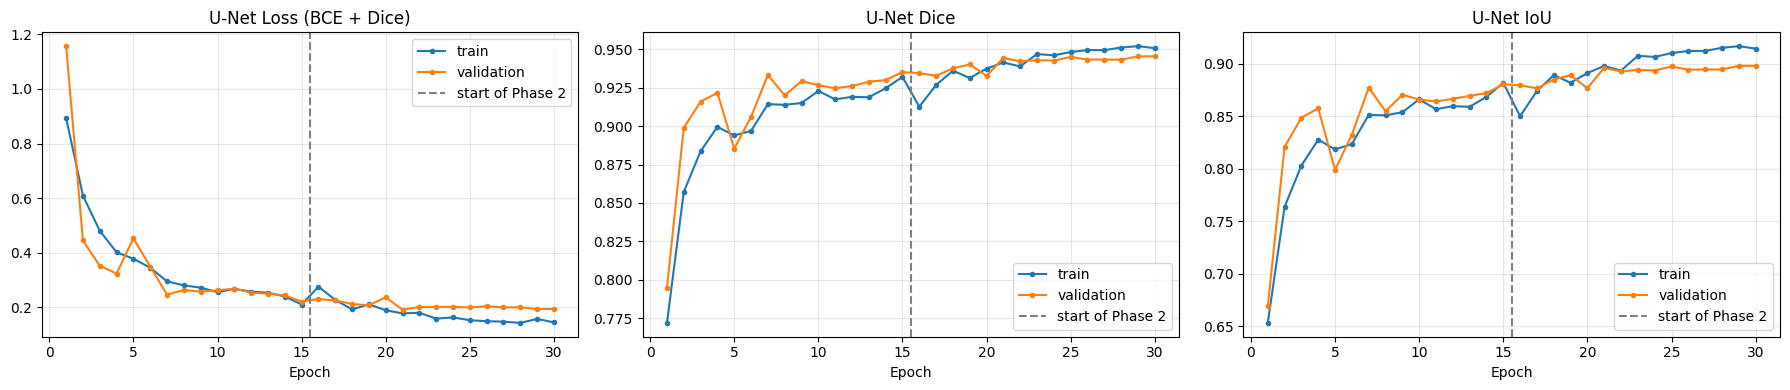

In [57]:
# Given: training curves of the U-Net
plot_history(seg_history, seg_phase_end,
             keys=[("train_loss", "val_loss"), ("train_dice", "val_dice"), ("train_iou", "val_iou")],
             titles=["U-Net Loss (BCE + Dice)", "U-Net Dice", "U-Net IoU"],
             save_path=os.path.join(RESULTS_DIR, "unet_curves.png"))

### Task 19 — Evaluate the U-Net (Step 17)
Write `evaluate_seg(model, loader)`: loop over the loader in eval mode (no gradients), accumulate `seg_loss`, `dice_score`, `iou_score` and `pixel_accuracy` (weighted by batch size) and **return** `(loss, dice, iou, pixel_acc)` averages. The calls below use it to produce the validation and test results.

In [58]:
@torch.no_grad()
def evaluate_seg(model, loader):
    model.eval()
    tot_loss = tot_dice = tot_iou = tot_acc = n = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        k = images.size(0)
        tot_loss += seg_loss(logits, masks).item() * k
        tot_dice += dice_score(logits, masks) * k
        tot_iou  += iou_score(logits, masks) * k
        tot_acc  += pixel_accuracy(logits, masks) * k
        n += k
    return tot_loss / n, tot_dice / n, tot_iou / n, tot_acc / n

In [60]:
# train metrics measured WITHOUT augmentation
seg_train_eval_loader = DataLoader(PetSegDataset(train_stems, train=False),
                                   batch_size=SEG_BATCH, shuffle=False, num_workers=2)

for name, ld in [("Train", seg_train_eval_loader), ("Val", seg_val_loader), ("Test", seg_test_loader)]:
    loss, dice, iou, pacc = evaluate_seg(unet, ld)
    print(f"{name:5s} | loss {loss:.4f} | Dice {dice:.4f} | IoU {iou:.4f} | pixel acc {pacc:.4f}")

Train | loss 0.1280 | Dice 0.9551 | IoU 0.9226 | pixel acc 0.9743
Val   | loss 0.1937 | Dice 0.9454 | IoU 0.8982 | pixel acc 0.9571
Test  | loss 0.2522 | Dice 0.9324 | IoU 0.8789 | pixel acc 0.9453


### Task 20 — Visualize the U-Net predictions (Step 17)
Take one batch from `seg_test_loader`, predict masks for up to **5 samples** (sigmoid, threshold 0.5) and display, for each sample, **four columns**: `Input | Ground truth | Prediction | Overlay`. In the overlay, colour the predicted pet region in red on top of the image. Save the figure as `results/unet_predictions.png`.

**Observation:** in which regions does the U-Net make mistakes (boundaries, thin parts, similar colours)? The U-Net segments the main body of the pet well. Errors are mostly at boundaries and in cluttered backgrounds. In the last image the cat is lying on a beige cushion with a white toy, and the model wrongly marks parts of the cushion as pet, and the toy and fur have similar colours. Small false blobs appear where the background is bright or textured (the lamp light in row 1, the blanket in rows 3 and 4). There are also small holes inside the white blanket and fur in row 4. Thin parts like ears and legs are mostly captured, but edges are slightly rough.

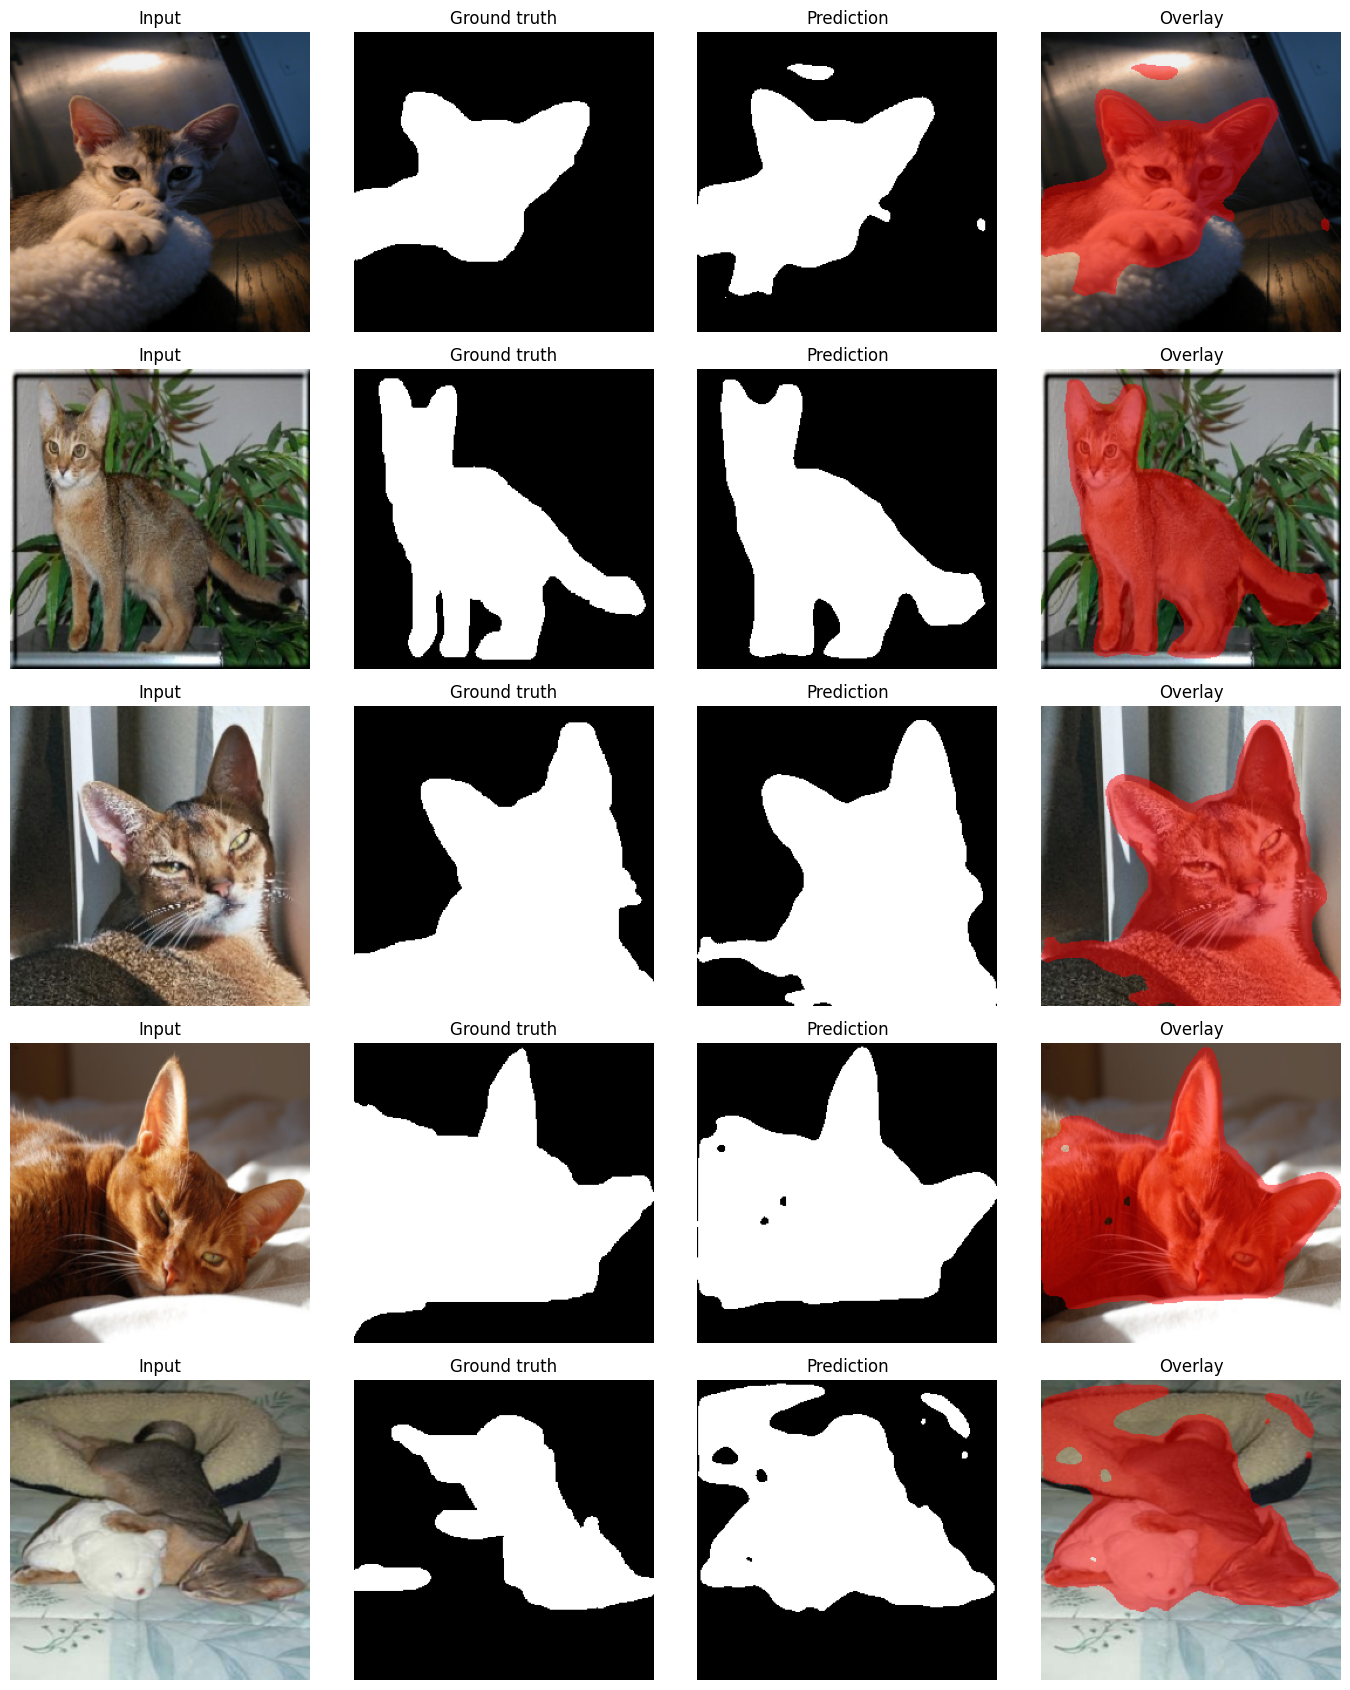

In [59]:
unet.eval()

images, masks = next(iter(seg_test_loader))
with torch.no_grad():
    logits = unet(images.to(device))
    preds = (torch.sigmoid(logits) > 0.5).float().cpu()

n_show = min(5, images.size(0))
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3.4 * n_show))
axes = np.atleast_2d(axes)

for i in range(n_show):
    img  = denorm(images[i])
    gt   = masks[i, 0].numpy()
    pr   = preds[i, 0].numpy()

    # overlay: predicted pet region in red on top of the image
    overlay = img.copy()
    region = pr > 0.5
    overlay[region] = 0.5 * overlay[region] + 0.5 * np.array([1.0, 0.0, 0.0])

    axes[i, 0].imshow(img);                axes[i, 0].set_title("Input")
    axes[i, 1].imshow(gt, cmap="gray");    axes[i, 1].set_title("Ground truth")
    axes[i, 2].imshow(pr, cmap="gray");    axes[i, 2].set_title("Prediction")
    axes[i, 3].imshow(overlay);            axes[i, 3].set_title("Overlay")
    for a in axes[i]:
        a.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "unet_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()

## Results Tables (fill in with YOUR results)
| ResNet-50 Metric | Result |
| --- | ---: |
| Training Accuracy | 1.000 |
| Validation Accuracy | 0.967 |
| Test Accuracy | 1.000 |
| Precision (macro) | 1.000 |
| Recall (macro) | 1.000 |
| F1-score (macro) | 1.000 |

| U-Net Metric | Result |
| --- | ---: |
| Training Loss | 0.1451 |
| Validation Loss | 0.1944 |
| Test Dice | 0.9324 |
| Test IoU | 0.8789 |

| Model | Dataset | Task | Main Metric | Result |
| --- | --- | --- | --- | ---: |
| ResNet-50 |Oxford Flowers-102 (5 classes, 200 images) | Classification | Accuracy | 1.000 |
| U-Net | Oxford-IIIT Pet (150 image/mask pairs)| Segmentation | Dice / IoU |0.9324 / 0.8789 |

---
# Uploading the Assignment to GitHub (Detailed Procedure)

**GitHub** is a website that stores your project in a *repository* ("repo") with full version history.

## 1. What to upload
```text
resnet-unet-finetuning-assignment/
│
├── notebook/
│   └── assignment_resnet_unet.ipynb      <- this notebook, saved WITH outputs
│
├── results/
│   ├── resnet_results.png
│   ├── resnet_confusion_matrix.png
│   ├── unet_predictions.png
│   ├── unet_curves.png
│   └── (csv tables)
│

```
**Do NOT upload:** the datasets, or the trained weights (`*.pth`). GitHub rejects any single file larger than **100 MB**, and a U-Net with a ResNet-50 encoder is larger than that. Put the dataset link in the README and share the weights through a Google Drive link if required.

## 2. Prepare the files from Colab
1. Make sure the notebook was run **top to bottom** so that all outputs/figures are visible.
2. **Download the notebook:** `File -> Download -> Download .ipynb`.
3. **Download the results:** your figures are in `/content/results` and in `MyDrive/DL_Assignment/results` (open the Colab *Files* sidebar, or download them from Drive).


## 3.Create a GitHub account and repository
1. Go to **https://github.com** -> **Sign up** (skip if you already have an account) and verify your e-mail.
2. Click the **+** icon (top right) -> **New repository**.
3. **Repository name:** `[Roll_no]-assignment`
4. **Description:** *Fine-tuning ResNet-50 and U-Net on small image datasets*.
5. Choose **Public** (or Private and add your instructor as a collaborator: *Settings -> Collaborators*).
6. then click **Create repository**.
## 4 - Command line (Git)
Run this on your computer in the project folder (install Git from https://git-scm.com).

```bash
# one-time configuration (use your GitHub name and e-mail)
git config --global user.name  "Your Name"
git config --global user.email "you@example.com"

# create the local repository and make the first commit
git init
git add .
git commit -m "Complete ResNet and U-Net assignment"
git branch -M main

# connect to GitHub and upload
git remote add origin https://github.com/<your-username>/resnet-unet-finetuning-assignment.git
git push -u origin main
```
* GitHub **no longer accepts your account password** for `git push`. When asked for a password, paste a **Personal Access Token**: GitHub -> *Settings -> Developer settings -> Personal access tokens -> Tokens (classic) -> Generate new token*, tick the `repo` scope, copy the token (it is shown only once). Never share a token or write it inside the notebook.
* If you created the repo with a README, run `git pull origin main --allow-unrelated-histories` once before pushing.
* To update later: `git add .` -> `git commit -m "message"` -> `git push`.
